<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/DT_Hancock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Dataset Shape: (332, 25)

Class Distribution
HPV
0    191
1    141
Name: count, dtype: int64

Training Patients: 265
Test Patients: 67

Number of Features: 25
Scaling: None - tree-based model

Training samples without SMOTE:
HPV
0    152
1    113
Name: count, dtype: int64

Classification Report

              precision    recall  f1-score   support

           0     0.7805    0.8205    0.8000        39
           1     0.7308    0.6786    0.7037        28

    accuracy                         0.7612        67
   macro avg     0.7556    0.7495    0.7519        67
weighted avg     0.7597    0.7612    0.7598        67

Confusion Matrix
[[32  7]
 [ 9 19]]

Accuracy:            0.7612
Balanced Accuracy:   0.7495
F1-score:            0.7037
AUC:                 0.7495

DECISION TREE42_HANCOCK SUMMARY
Model : Decision Tree
Input Features : 25
Learning Rate : N/A
Optimiser : N/A
Scaling : None - tree-based model
Class Weights : Automatic (training labels)
SMOTE : No
P

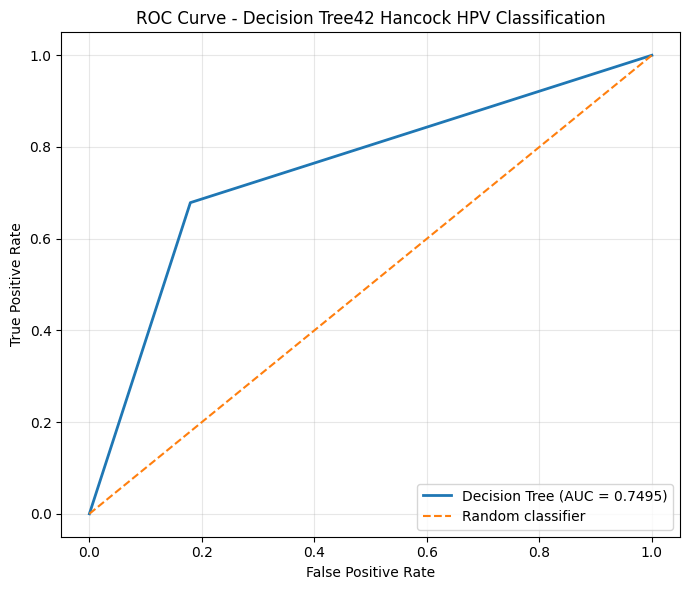

ROC AUC: 0.7495


In [1]:
# ============================================================
# DT42_Hancock
# No SMOTE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os,json,random,numpy as np,pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report,confusion_matrix,balanced_accuracy_score,roc_auc_score,f1_score,roc_curve
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED=42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"]=str(SEED)

# ------------------------------------------------------------
# Read Data
# ------------------------------------------------------------

with open('/content/drive/MyDrive/clinical_data.json') as f:
    clinical=pd.DataFrame(json.load(f))
with open('/content/drive/MyDrive/pathological_data.json') as f:
    pathology=pd.DataFrame(json.load(f))

df=clinical.merge(pathology,on='patient_id',how='inner')

# ------------------------------------------------------------
# HPV Labels
# ------------------------------------------------------------

df=df[df['hpv_association_p16'].isin(['positive','negative'])].copy()
df['HPV']=df['hpv_association_p16'].map({'negative':0,'positive':1})

# ------------------------------------------------------------
# Build Modelling Dataset
# ------------------------------------------------------------

df_model=df[['age_at_initial_diagnosis','sex','smoking_status','primarily_metastasis','first_treatment_intent','first_treatment_modality','days_to_first_treatment','adjuvant_treatment_intent','adjuvant_radiotherapy','adjuvant_radiotherapy_modality','adjuvant_systemic_therapy','adjuvant_systemic_therapy_modality','adjuvant_radiochemotherapy','primary_tumor_site','pT_stage','pN_stage','histologic_type','number_of_positive_lymph_nodes','number_of_resected_lymph_nodes','perinodal_invasion','lymphovascular_invasion_L','vascular_invasion_V','perineural_invasion_Pn','resection_status','infiltration_depth_in_mm','HPV']].copy()

# ------------------------------------------------------------
# Features and Target
# ------------------------------------------------------------

X=df_model.drop(columns=['HPV'])
y=df_model['HPV']
n_features=X.shape[1]

print("Dataset Shape:",X.shape)
print("\nClass Distribution")
print(y.value_counts())

# ------------------------------------------------------------
# Train/Test Split
# ------------------------------------------------------------

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=SEED,stratify=y
)
X_train=X_train.copy()
X_test=X_test.copy()

print("\nTraining Patients:",len(y_train))
print("Test Patients:",len(y_test))

# ------------------------------------------------------------
# Missing Values
# Train-derived values ONLY
# ------------------------------------------------------------

cat_cols=['sex','smoking_status','primarily_metastasis','first_treatment_intent','first_treatment_modality','adjuvant_treatment_intent','adjuvant_radiotherapy','adjuvant_radiotherapy_modality','adjuvant_systemic_therapy','adjuvant_systemic_therapy_modality','adjuvant_radiochemotherapy','primary_tumor_site','pT_stage','pN_stage','histologic_type','perinodal_invasion','lymphovascular_invasion_L','vascular_invasion_V','perineural_invasion_Pn','resection_status']
num_cols=['age_at_initial_diagnosis','days_to_first_treatment','number_of_positive_lymph_nodes','number_of_resected_lymph_nodes','infiltration_depth_in_mm']

for col in cat_cols:
    value=X_train[col].mode()[0]
    X_train[col]=X_train[col].fillna(value)
    X_test[col]=X_test[col].fillna(value)

for col in num_cols:
    value=X_train[col].median()
    X_train[col]=X_train[col].fillna(value)
    X_test[col]=X_test[col].fillna(value)

# ------------------------------------------------------------
# Encoding
# Train-only encoding
# ------------------------------------------------------------

encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
X_train[cat_cols]=encoder.fit_transform(X_train[cat_cols].astype(str))
X_test[cat_cols]=encoder.transform(X_test[cat_cols].astype(str))

print("\nNumber of Features:",n_features)
print("Scaling: None - tree-based model")

# ------------------------------------------------------------
# No SMOTE
# ------------------------------------------------------------

print("\nTraining samples without SMOTE:")
print(pd.Series(y_train).value_counts())

# ------------------------------------------------------------
# Decision Tree Model
# ------------------------------------------------------------

class_counts=np.bincount(y_train)
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weight_dict={i:class_weights[i] for i in range(len(class_weights))}

model=DecisionTreeClassifier(
    class_weight=class_weight_dict,
    random_state=SEED
)
model.fit(X_train,y_train)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predicted=model.predict(X_test)
probabilities=model.predict_proba(X_test)[:,1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print()
print("Classification Report\n")
print(classification_report(y_test,predicted,digits=4))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm=confusion_matrix(y_test,predicted)
print("Confusion Matrix")
print(cm)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy=(predicted==y_test).sum()/len(y_test)
bal_acc=balanced_accuracy_score(y_test,predicted)
f1=f1_score(y_test,predicted)
auc=roc_auc_score(y_test,probabilities)

print()
print(f"Accuracy:            {accuracy:.4f}")
print(f"Balanced Accuracy:   {bal_acc:.4f}")
print(f"F1-score:            {f1:.4f}")
print(f"AUC:                 {auc:.4f}")

# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

print()
print("====================================")
print("DECISION TREE42_HANCOCK SUMMARY")
print("====================================")
print("Model : Decision Tree")
print("Input Features :",n_features)
print("Learning Rate : N/A")
print("Optimiser : N/A")
print("Scaling : None - tree-based model")
print("Class Weights : Automatic (training labels)")
print("SMOTE : No")
print("Preprocessing : Train-only")
print("Imputation : Train-derived mode/median")
print("Encoding : Train-fitted OrdinalEncoder")
print("Training Patients :",len(y_train))
print("Test Patients :",len(y_test))
print("Seed :",SEED)
print()
print("Final Results")
print("---------------------------")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Balanced Accuracy   : {bal_acc:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"AUC                 : {auc:.4f}")
print()
print("Confusion Matrix")
print(cm)
print()
print("Analysis Complete.")

# ============================================================
# ROC / AUC CURVE
# ============================================================

y_score=probabilities
fpr,tpr,thresholds=roc_curve(y_test,y_score)
auc_curve=roc_auc_score(y_test,y_score)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,linewidth=2,label=f'Decision Tree (AUC = {auc_curve:.4f})')
plt.plot([0,1],[0,1],linestyle='--',linewidth=1.5,label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree42 Hancock HPV Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {auc_curve:.4f}")